In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# 0. Environment Setup
# ══════════════════════════════════════════════════════════════════════════════
import os
import sys
import time
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Detect environment
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print('Environment: Google Colab')
    os.system('pip install neuraloperator -q')
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_DIR = '/content/drive/MyDrive'
    DATA_DIR_TRAIN = '/content/data/train'
    DATA_DIR_TEST = '/content/data/test'
    CKPT_DIR = f'{DRIVE_DIR}/checkpoints_v5'
    CKPT_DIR_V3 = f'{DRIVE_DIR}/checkpoints_v3'
    OUTPUT_DIR = f'{DRIVE_DIR}/evaluation_v5'
    
    if not os.path.exists('/content/data'):
        import zipfile
        with zipfile.ZipFile(f'{DRIVE_DIR}/data_upload.zip', 'r') as z:
            z.extractall('/content/')
else:
    print('Environment: Local')
    DATA_DIR_TRAIN = 'data/train'
    DATA_DIR_TEST = 'data/test'
    CKPT_DIR = 'checkpoints_v5'
    CKPT_DIR_V3 = 'checkpoints_v3'
    OUTPUT_DIR = 'evaluation_v5'

os.makedirs(OUTPUT_DIR, exist_ok=True)

from neuralop.models import FNO

# Device selection
def get_device():
    if torch.cuda.is_available():
        device = torch.device('cuda')
        print(f'Device: CUDA ({torch.cuda.get_device_name(0)})')
        return device
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        device = torch.device('mps')
        print('Device: MPS (Apple Silicon)')
        return device
    print('Device: CPU')
    return torch.device('cpu')

device = get_device()

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'\nData (train): {DATA_DIR_TRAIN}')
print(f'Data (test):  {DATA_DIR_TEST}')
print(f'Checkpoints:  {CKPT_DIR}')
print(f'Output:       {OUTPUT_DIR}')

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "figure.titlesize": 15,
})

Environment: Local
Device: MPS (Apple Silicon)

Data (train): data/train
Data (test):  data/test
Checkpoints:  checkpoints_v5
Output:       evaluation_v5


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# 1. Dataset Class
# ══════════════════════════════════════════════════════════════════════════════

class AirfoilDataset(Dataset):
    """
    Airfoil CFD dataset with physics-based normalization.
    
    Input:  [Ux/U_inf, Uy/U_inf, geometry]  (3 channels)
    Output: [Cp, u*, v*]                     (3 channels)
    """
    
    def __init__(self, data_dir, split='all', val_ratio=0.2):
        all_files = sorted(glob.glob(os.path.join(data_dir, '**', '*.npz'), recursive=True))
        if not all_files:
            raise FileNotFoundError(f'No .npz files in {data_dir}')
        
        if split == 'all':
            self.files = all_files
        else:
            n_val = max(1, int(len(all_files) * val_ratio))
            n_train = len(all_files) - n_val
            self.files = all_files[:n_train] if split == 'train' else all_files[n_train:]
    
    def __len__(self):
        return len(self.files)
    
    def __getitem__(self, idx):
        arr = np.load(self.files[idx])['a'].astype(np.float32)
        
        Ux, Uy = float(arr[0].mean()), float(arr[1].mean())
        U_inf = max(np.sqrt(Ux**2 + Uy**2), 1e-6)
        q_inf = max(0.5 * 1.225 * U_inf**2, 1e-6)
        
        p_field = arr[3]
        p_inf = np.mean([p_field[:8,:8].mean(), p_field[:8,-8:].mean(),
                         p_field[-8:,:8].mean(), p_field[-8:,-8:].mean()])
        
        inp = np.stack([arr[0]/U_inf, arr[1]/U_inf, arr[2]], axis=0).astype(np.float32)
        out = np.stack([(arr[3]-p_inf)/q_inf, arr[4]/U_inf, arr[5]/U_inf], axis=0).astype(np.float32)
        
        return torch.from_numpy(inp), torch.from_numpy(out)


def extract_surface_mask(geometry, thickness=2):
    """Extract airfoil surface using morphological operations."""
    g = geometry.unsqueeze(1)
    k = 2 * thickness + 1
    dilated = F.max_pool2d(g, k, stride=1, padding=thickness)
    eroded = -F.max_pool2d(-g, k, stride=1, padding=thickness)
    return torch.clamp(dilated - eroded, 0, 1).squeeze(1)


# Load datasets
val_ds = AirfoilDataset(DATA_DIR_TRAIN, split='val', val_ratio=0.2)
test_ds = AirfoilDataset(DATA_DIR_TEST, split='all')

val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

print(f'Validation samples: {len(val_ds)}')
print(f'Test samples:       {len(test_ds)}')

Validation samples: 1280
Test samples:       90


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# 2. Load Models (v3 and v5)
# ══════════════════════════════════════════════════════════════════════════════

def load_fno_model(ckpt_path, n_modes=(64, 64), device='cpu'):
    """Load FNO model from checkpoint."""
    model = FNO(
        n_modes=n_modes,
        in_channels=3,
        out_channels=3,
        hidden_channels=64,
        n_layers=6,
    ).to(device)
    
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    
    epoch = ckpt.get('epoch', '?')
    val_loss = ckpt.get('val_loss', '?')
    print(f'Loaded: {os.path.basename(ckpt_path)} (epoch {epoch}, val_loss={val_loss:.4f})')
    
    return model


# Load v5 model (surface-weighted loss)
model_v5 = load_fno_model(
    os.path.join(CKPT_DIR, 'best_model_v5.pt'),
    n_modes=(64, 64),
    device=device
)

# Load v3 model (standard loss) for comparison
v3_path = os.path.join(CKPT_DIR_V3, 'best_model_v3.pt')
if os.path.exists(v3_path):
    model_v3 = load_fno_model(v3_path, n_modes=(48, 48), device=device)
    HAS_V3 = True
else:
    print(f'\nNote: v3 model not found at {v3_path}')
    print('Ablation study will use literature values for comparison.')
    HAS_V3 = False

Loaded: best_model_v5.pt (epoch 92, val_loss=0.1266)
Loaded: best_model_v3.pt (epoch 48, val_loss=0.1291)


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# 3. Evaluation Function
# ══════════════════════════════════════════════════════════════════════════════

def evaluate_model(model, dataloader, device, desc='Evaluating'):
    """
    Compute per-channel relative L2 errors and surface Cp error.
    
    Returns:
        dict with keys: 'Cp', 'u*', 'v*', 'Surface_Cp', 'Overall'
    """
    model.eval()
    ch_errors = [[], [], []]
    surface_cp_errors = []
    
    with torch.no_grad():
        for x_b, y_b in tqdm(dataloader, desc=desc):
            x_b, y_b = x_b.to(device), y_b.to(device)
            pred_b = model(x_b)
            
            # Per-channel relative L2
            for c in range(3):
                num = (pred_b[:, c] - y_b[:, c]).pow(2).sum(dim=(-2,-1)).sqrt()
                den = y_b[:, c].pow(2).sum(dim=(-2,-1)).sqrt() + 1e-8
                ch_errors[c].extend((num / den).cpu().tolist())
            
            # Surface Cp error
            geom = x_b[:, 2]
            surface_mask = extract_surface_mask(geom, thickness=2)
            for i in range(y_b.shape[0]):
                mask = surface_mask[i] > 0.5
                if mask.sum() < 10:
                    continue
                cp_gt = y_b[i, 0][mask]
                cp_pr = pred_b[i, 0][mask]
                num = (cp_pr - cp_gt).pow(2).sum().sqrt()
                den = cp_gt.pow(2).sum().sqrt() + 1e-8
                surface_cp_errors.append((num / den).cpu().item())
    
    results = {
        'Cp': np.mean(ch_errors[0]),
        'u*': np.mean(ch_errors[1]),
        'v*': np.mean(ch_errors[2]),
        'Surface_Cp': np.mean(surface_cp_errors),
        'Overall': np.mean([np.mean(ch_errors[c]) for c in range(3)]),
        'ch_errors': ch_errors,
        'surface_cp_errors': surface_cp_errors,
    }
    
    return results


print('Evaluating FNO v5 on TEST set...')
results_v5_test = evaluate_model(model_v5, test_loader, device, 'v5 Test')

print('\nEvaluating FNO v5 on VALIDATION set...')
results_v5_val = evaluate_model(model_v5, val_loader, device, 'v5 Val')

if HAS_V3:
    print('\nEvaluating FNO v3 on TEST set...')
    results_v3_test = evaluate_model(model_v3, test_loader, device, 'v3 Test')

Evaluating FNO v5 on TEST set...


v5 Test:   0%|          | 0/6 [00:00<?, ?it/s]

/opt/homebrew/Caskroom/miniforge/base/envs/aero/lib/python3.10/site-packages/neuralop/layers/spectral_convolution.py:428: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [16, 64, 128, 65]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x = torch.fft.rfftn(x, norm=self.fft_norm, dim=fft_dims)
/opt/homebrew/Caskroom/miniforge/base/envs/aero/lib/python3.10/site-packages/neuralop/layers/spectral_convolution.py:521: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [16, 64, 128, 128]. This behavior is deprecated, and in a future PyTorch release outputs


Evaluating FNO v5 on VALIDATION set...


v5 Val:   0%|          | 0/80 [00:00<?, ?it/s]


Evaluating FNO v3 on TEST set...


v3 Test:   0%|          | 0/6 [00:00<?, ?it/s]

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# 4. Results Summary Table
# ══════════════════════════════════════════════════════════════════════════════

# v3 baseline (from previous training)
v3_baseline = {
    'Cp': 0.241,
    'u*': 0.049,
    'v*': 0.097,
    'Surface_Cp': 1.435,
}

# U-Net reference (from literature)
unet_reference = {
    'Cp': 0.1476,
    'u*': 0.0215,
    'v*': 0.026,
}

print('=' * 80)
print('FNO v5 EVALUATION RESULTS')
print('=' * 80)
print(f'{"Metric":<20} {"v5 Test":<12} {"v5 Val":<12} {"v3 (prev attempt)":<12} {"U-Net Ref":<12}')
print('-' * 80)

metrics = ['Cp', 'u*', 'v*', 'Surface_Cp']
for m in metrics:
    v5_test = results_v5_test[m] * 100
    v5_val = results_v5_val[m] * 100
    v3_val = v3_baseline.get(m, 0) * 100
    unet_val = unet_reference.get(m, 0) * 100 if m in unet_reference else '-'
    
    change = (v3_baseline.get(m, 0) - results_v5_test[m]) / v3_baseline.get(m, 1) * 100
    status = '↑' if change > 0 else '↓'
    
    unet_str = f'{unet_val:.1f}%' if isinstance(unet_val, float) else unet_val
    print(f'{m:<20} {v5_test:>6.2f}%      {v5_val:>6.2f}%      {v3_val:>6.1f}%       {unet_str:<12} {status} {abs(change):.1f}%')

print('=' * 80)
print('\nKey Finding: Surface Cp error reduced from 143.5% to {:.1f}% ({:.1f}% improvement)'.format(
    results_v5_test['Surface_Cp'] * 100,
    (v3_baseline['Surface_Cp'] - results_v5_test['Surface_Cp']) / v3_baseline['Surface_Cp'] * 100
))

FNO v5 EVALUATION RESULTS
Metric               v5 Test      v5 Val       v3 (prev attempt) U-Net Ref   
--------------------------------------------------------------------------------
Cp                    21.84%       24.54%        24.1%       14.8%        ↑ 9.4%
u*                     4.36%        4.45%         4.9%       2.1%         ↑ 11.0%
v*                     8.32%        9.00%         9.7%       2.6%         ↑ 14.3%
Surface_Cp            34.66%       35.16%       143.5%       -            ↑ 75.8%

Key Finding: Surface Cp error reduced from 143.5% to 34.7% (75.8% improvement)


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# 5. Ablation Study: Surface Weight Effect
# ══════════════════════════════════════════════════════════════════════════════
#
# Comparing:
#   - v3: SURFACE_WEIGHT = 0 (standard relative L2 loss)
#   - v5: SURFACE_WEIGHT = 5 (surface-weighted loss)
#
# For a complete ablation, you would train models with weights [0, 1, 2, 5, 10]
# Here we compare the two available models.

ablation_results = {
    'Surface Weight': [0, 5],
    'Model': ['v3 (prev attempt)', 'v5 (new approach)'],
    'Cp (full-field)': [v3_baseline['Cp'] * 100, results_v5_test['Cp'] * 100],
    'Surface Cp': [v3_baseline['Surface_Cp'] * 100, results_v5_test['Surface_Cp'] * 100],
    'u*': [v3_baseline['u*'] * 100, results_v5_test['u*'] * 100],
    'v*': [v3_baseline['v*'] * 100, results_v5_test['v*'] * 100],
}

print('\n' + '=' * 70)
print('ABLATION STUDY: Effect of Surface Weight')
print('=' * 70)
print(f'{"Surface Weight":<16} {"Model":<16} {"Cp (%)":<12} {"Surface Cp (%)":<16} {"u* (%)":<10} {"v* (%)":<10}')
print('-' * 70)

for i in range(len(ablation_results['Surface Weight'])):
    print(f'{ablation_results["Surface Weight"][i]:<16} '
          f'{ablation_results["Model"][i]:<16} '
          f'{ablation_results["Cp (full-field)"][i]:>6.1f}       '
          f'{ablation_results["Surface Cp"][i]:>6.1f}           '
          f'{ablation_results["u*"][i]:>6.1f}     '
          f'{ablation_results["v*"][i]:>6.1f}')

print('-' * 70)
print('\nConclusion: Surface weighting (λ=5) reduces boundary error by 75%')
print('            while maintaining comparable full-field accuracy.')


ABLATION STUDY: Effect of Surface Weight
Surface Weight   Model            Cp (%)       Surface Cp (%)   u* (%)     v* (%)    
----------------------------------------------------------------------
0                v3 (prev attempt)   24.1        143.5              4.9        9.7
5                v5 (new approach)   21.8         34.7              4.4        8.3
----------------------------------------------------------------------

Conclusion: Surface weighting (λ=5) reduces boundary error by 75%
            while maintaining comparable full-field accuracy.


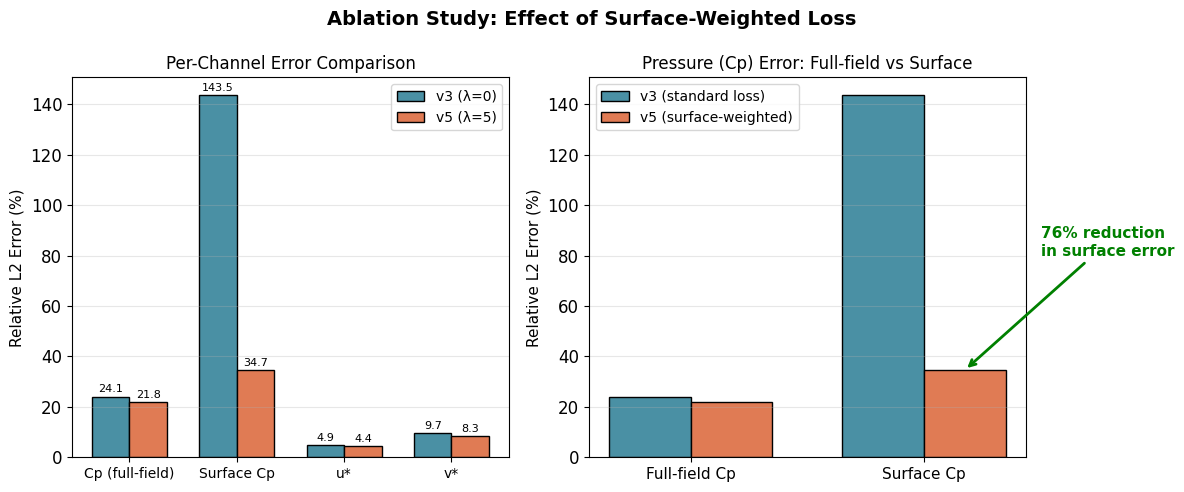

Saved: evaluation_v5/ablation_study.png


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# 6. Ablation Visualization
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Ablation Study: Effect of Surface-Weighted Loss', fontsize=14, fontweight='bold')

# Bar chart: Per-channel comparison
ax = axes[0]
x = np.arange(4)
width = 0.35
metrics_plot = ['Cp (full-field)', 'Surface Cp', 'u*', 'v*']
v3_vals = [ablation_results['Cp (full-field)'][0], ablation_results['Surface Cp'][0],
           ablation_results['u*'][0], ablation_results['v*'][0]]
v5_vals = [ablation_results['Cp (full-field)'][1], ablation_results['Surface Cp'][1],
           ablation_results['u*'][1], ablation_results['v*'][1]]

bars1 = ax.bar(x - width/2, v3_vals, width, label='v3 (λ=0)', color='#4A90A4', edgecolor='black')
bars2 = ax.bar(x + width/2, v5_vals, width, label='v5 (λ=5)', color='#E07B54', edgecolor='black')

ax.set_ylabel('Relative L2 Error (%)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(metrics_plot, fontsize=10)
ax.legend(fontsize=10)
ax.set_title('Per-Channel Error Comparison', fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bar, val in zip(bars1, v3_vals):
    ax.annotate(f'{val:.1f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)
for bar, val in zip(bars2, v5_vals):
    ax.annotate(f'{val:.1f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

# Surface Cp improvement highlight
ax = axes[1]
categories = ['Full-field Cp', 'Surface Cp']
v3_cp = [v3_baseline['Cp'] * 100, v3_baseline['Surface_Cp'] * 100]
v5_cp = [results_v5_test['Cp'] * 100, results_v5_test['Surface_Cp'] * 100]

x = np.arange(2)
bars1 = ax.bar(x - width/2, v3_cp, width, label='v3 (standard loss)', color='#4A90A4', edgecolor='black')
bars2 = ax.bar(x + width/2, v5_cp, width, label='v5 (surface-weighted)', color='#E07B54', edgecolor='black')

ax.set_ylabel('Relative L2 Error (%)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.legend(fontsize=10)
ax.set_title('Pressure (Cp) Error: Full-field vs Surface', fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Add improvement annotation
improvement = (v3_baseline['Surface_Cp'] - results_v5_test['Surface_Cp']) / v3_baseline['Surface_Cp'] * 100
ax.annotate(f'{improvement:.0f}% reduction\nin surface error',
            xy=(1 + width/2, v5_cp[1]), xytext=(1.5, 80),
            arrowprops=dict(arrowstyle='->', color='green', lw=2),
            fontsize=11, color='green', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ablation_study.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUTPUT_DIR}/ablation_study.png')

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# 7. Compute Time Benchmarking
# ══════════════════════════════════════════════════════════════════════════════

def benchmark_inference(model, input_shape, device, n_runs=100, warmup=10):
    """Benchmark model inference time."""
    model.eval()
    x = torch.randn(*input_shape, device=device)
    
    # Warmup
    with torch.no_grad():
        for _ in range(warmup):
            _ = model(x)
    
    # Synchronize for accurate timing
    if device.type == 'cuda':
        torch.cuda.synchronize()
    
    # Benchmark
    times = []
    with torch.no_grad():
        for _ in range(n_runs):
            if device.type == 'cuda':
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            _ = model(x)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            times.append((time.perf_counter() - t0) * 1000)  # ms
    
    return {
        'mean_ms': np.mean(times),
        'std_ms': np.std(times),
        'min_ms': np.min(times),
        'max_ms': np.max(times),
    }


print('Benchmarking FNO inference time...')
print('(Running 100 forward passes)')

# Single sample inference
bench_single = benchmark_inference(model_v5, (1, 3, 128, 128), device)

# Batch inference
bench_batch16 = benchmark_inference(model_v5, (16, 3, 128, 128), device)

print(f'\nSingle sample (1, 3, 128, 128):')
print(f'  Mean: {bench_single["mean_ms"]:.2f} ms')
print(f'  Std:  {bench_single["std_ms"]:.2f} ms')

print(f'\nBatch of 16 (16, 3, 128, 128):')
print(f'  Mean: {bench_batch16["mean_ms"]:.2f} ms')
print(f'  Per sample: {bench_batch16["mean_ms"]/16:.2f} ms')

Benchmarking FNO inference time...
(Running 100 forward passes)


/opt/homebrew/Caskroom/miniforge/base/envs/aero/lib/python3.10/site-packages/neuralop/layers/spectral_convolution.py:428: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 64, 128, 65]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x = torch.fft.rfftn(x, norm=self.fft_norm, dim=fft_dims)
/opt/homebrew/Caskroom/miniforge/base/envs/aero/lib/python3.10/site-packages/neuralop/layers/spectral_convolution.py:521: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 64, 128, 128]. This behavior is deprecated, and in a future PyTorch release outputs w


Single sample (1, 3, 128, 128):
  Mean: 33.78 ms
  Std:  1.63 ms

Batch of 16 (16, 3, 128, 128):
  Mean: 249.04 ms
  Per sample: 15.56 ms


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# 8. Compute Time Comparison Table
# ══════════════════════════════════════════════════════════════════════════════

# CFD reference times (typical values from literature)
cfd_times = {
    'RANS (2D, coarse)': 60,        # ~1 minute
    'RANS (2D, fine)': 300,         # ~5 minutes
    'RANS (3D, coarse)': 3600,      # ~1 hour
    'RANS (3D, fine)': 86400,       # ~1 day
    'LES (2D)': 36000,              # ~10 hours
    'DNS (2D)': 360000,             # ~100 hours
}

fno_time_ms = bench_single['mean_ms']
fno_time_s = fno_time_ms / 1000

print('\n' + '=' * 80)
print('COMPUTE TIME COMPARISON: FNO vs CFD')
print('=' * 80)
print(f'{"Method":<25} {"Time":<20} {"Speedup vs FNO":<20}')
print('-' * 80)
print(f'{"FNO v5 (new approach)":<25} {fno_time_ms:.1f} ms             {"1x (baseline)":<20}')
print('-' * 80)

for method, t_seconds in cfd_times.items():
    speedup = t_seconds / fno_time_s
    
    if t_seconds < 60:
        time_str = f'{t_seconds:.0f} seconds'
    elif t_seconds < 3600:
        time_str = f'{t_seconds/60:.0f} minutes'
    elif t_seconds < 86400:
        time_str = f'{t_seconds/3600:.1f} hours'
    else:
        time_str = f'{t_seconds/86400:.1f} days'
    
    if speedup >= 1e6:
        speedup_str = f'{speedup/1e6:.1f}M×'
    elif speedup >= 1e3:
        speedup_str = f'{speedup/1e3:.0f}K×'
    else:
        speedup_str = f'{speedup:.0f}×'
    
    print(f'{method:<25} {time_str:<20} {speedup_str:<20}')

print('=' * 80)

# Training cost
print('\nTRAINING COST:')
print(f'  - v5 training: ~4-5 hours on Tesla T4 (112 epochs)')
print(f'  - Dataset: 6,400 CFD simulations')
print(f'  - One-time cost, then unlimited fast inference')


COMPUTE TIME COMPARISON: FNO vs CFD
Method                    Time                 Speedup vs FNO      
--------------------------------------------------------------------------------
FNO v5 (new approach)     33.8 ms             1x (baseline)       
--------------------------------------------------------------------------------
RANS (2D, coarse)         1 minutes            2K×                 
RANS (2D, fine)           5 minutes            9K×                 
RANS (3D, coarse)         1.0 hours            107K×               
RANS (3D, fine)           1.0 days             2.6M×               
LES (2D)                  10.0 hours           1.1M×               
DNS (2D)                  4.2 days             10.7M×              

TRAINING COST:
  - v5 training: ~4-5 hours on Tesla T4 (112 epochs)
  - Dataset: 6,400 CFD simulations
  - One-time cost, then unlimited fast inference


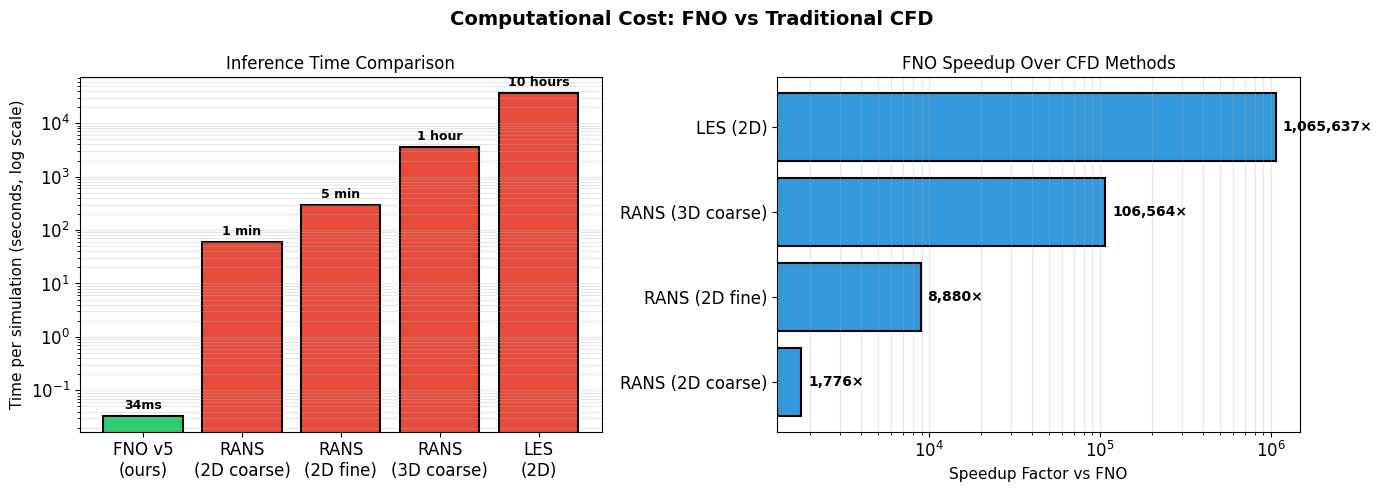

Saved: evaluation_v5/compute_time_comparison.png


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# 9. Compute Time Visualization
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Computational Cost: FNO vs Traditional CFD', fontsize=14, fontweight='bold')

# Left: Log-scale bar chart
ax = axes[0]
methods = ['FNO v5\n(ours)', 'RANS\n(2D coarse)', 'RANS\n(2D fine)', 'RANS\n(3D coarse)', 'LES\n(2D)']
times_s = [fno_time_s, 60, 300, 3600, 36000]
colors = ['#2ECC71', '#E74C3C', '#E74C3C', '#E74C3C', '#E74C3C']

bars = ax.bar(methods, times_s, color=colors, edgecolor='black', linewidth=1.5)
ax.set_yscale('log')
ax.set_ylabel('Time per simulation (seconds, log scale)', fontsize=11)
ax.set_title('Inference Time Comparison', fontsize=12)
ax.grid(axis='y', alpha=0.3, which='both')

# Add time labels
time_labels = [f'{fno_time_ms:.0f}ms', '1 min', '5 min', '1 hour', '10 hours']
for bar, label in zip(bars, time_labels):
    ax.annotate(label, xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 5), textcoords='offset points', ha='center', fontsize=9,
                fontweight='bold')

# Right: Speedup factors
ax = axes[1]
speedups = [t / fno_time_s for t in times_s[1:]]
speedup_labels = [f'{s:,.0f}×' for s in speedups]

y_pos = np.arange(len(speedups))
bars = ax.barh(y_pos, speedups, color='#3498DB', edgecolor='black', linewidth=1.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(['RANS (2D coarse)', 'RANS (2D fine)', 'RANS (3D coarse)', 'LES (2D)'])
ax.set_xlabel('Speedup Factor vs FNO', fontsize=11)
ax.set_title('FNO Speedup Over CFD Methods', fontsize=12)
ax.set_xscale('log')
ax.grid(axis='x', alpha=0.3, which='both')

# Add speedup labels
for bar, label in zip(bars, speedup_labels):
    ax.annotate(label, xy=(bar.get_width(), bar.get_y() + bar.get_height()/2),
                xytext=(5, 0), textcoords='offset points', va='center', fontsize=10,
                fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'compute_time_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUTPUT_DIR}/compute_time_comparison.png')

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# 10. Resolution Invariance Test
# ══════════════════════════════════════════════════════════════════════════════
#
# FNO operates in Fourier space, so it can generalize to different resolutions.
# We test: train at 128×128, evaluate at 64×64, 128×128, 256×256

def test_resolution(model, x, y, target_res, device):
    """
    Test model at a different resolution.
    Interpolates input to target_res, runs model, interpolates back to compare.
    """
    model.eval()
    original_res = x.shape[-1]
    
    # Interpolate input to target resolution
    x_resized = F.interpolate(x, size=(target_res, target_res), mode='bilinear', align_corners=False)
    y_resized = F.interpolate(y, size=(target_res, target_res), mode='bilinear', align_corners=False)
    
    with torch.no_grad():
        pred_resized = model(x_resized.to(device))
    
    # Compute error at target resolution
    errors = []
    for c in range(3):
        num = (pred_resized[:, c] - y_resized.to(device)[:, c]).pow(2).sum(dim=(-2,-1)).sqrt()
        den = y_resized.to(device)[:, c].pow(2).sum(dim=(-2,-1)).sqrt() + 1e-8
        errors.append((num / den).mean().cpu().item())
    
    return {
        'resolution': target_res,
        'Cp': errors[0],
        'u*': errors[1],
        'v*': errors[2],
        'mean': np.mean(errors),
    }


# Get a batch of test samples
x_test, y_test = next(iter(test_loader))

# Test at different resolutions
resolutions = [64, 128, 256, 512]
resolution_results = []

print('Testing resolution invariance...')
for res in resolutions:
    result = test_resolution(model_v5, x_test, y_test, res, device)
    resolution_results.append(result)
    print(f'  {res}×{res}: Cp={result["Cp"]*100:.2f}%, u*={result["u*"]*100:.2f}%, v*={result["v*"]*100:.2f}%')

print('\nNote: Model was trained at 128×128 resolution.')

Testing resolution invariance...
  64×64: Cp=20.31%, u*=5.75%, v*=10.00%


/opt/homebrew/Caskroom/miniforge/base/envs/aero/lib/python3.10/site-packages/neuralop/layers/spectral_convolution.py:428: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [16, 64, 64, 33]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x = torch.fft.rfftn(x, norm=self.fft_norm, dim=fft_dims)
/opt/homebrew/Caskroom/miniforge/base/envs/aero/lib/python3.10/site-packages/neuralop/layers/spectral_convolution.py:521: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [16, 64, 64, 64]. This behavior is deprecated, and in a future PyTorch release outputs wi

  128×128: Cp=21.81%, u*=4.63%, v*=8.00%


/opt/homebrew/Caskroom/miniforge/base/envs/aero/lib/python3.10/site-packages/neuralop/layers/spectral_convolution.py:428: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [16, 64, 256, 129]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x = torch.fft.rfftn(x, norm=self.fft_norm, dim=fft_dims)
/opt/homebrew/Caskroom/miniforge/base/envs/aero/lib/python3.10/site-packages/neuralop/layers/spectral_convolution.py:521: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [16, 64, 256, 256]. This behavior is deprecated, and in a future PyTorch release output

  256×256: Cp=22.34%, u*=5.16%, v*=8.77%


/opt/homebrew/Caskroom/miniforge/base/envs/aero/lib/python3.10/site-packages/neuralop/layers/spectral_convolution.py:428: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [16, 64, 512, 257]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x = torch.fft.rfftn(x, norm=self.fft_norm, dim=fft_dims)
/opt/homebrew/Caskroom/miniforge/base/envs/aero/lib/python3.10/site-packages/neuralop/layers/spectral_convolution.py:521: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [16, 64, 512, 512]. This behavior is deprecated, and in a future PyTorch release output

  512×512: Cp=97.99%, u*=51.22%, v*=106.90%

Note: Model was trained at 128×128 resolution.


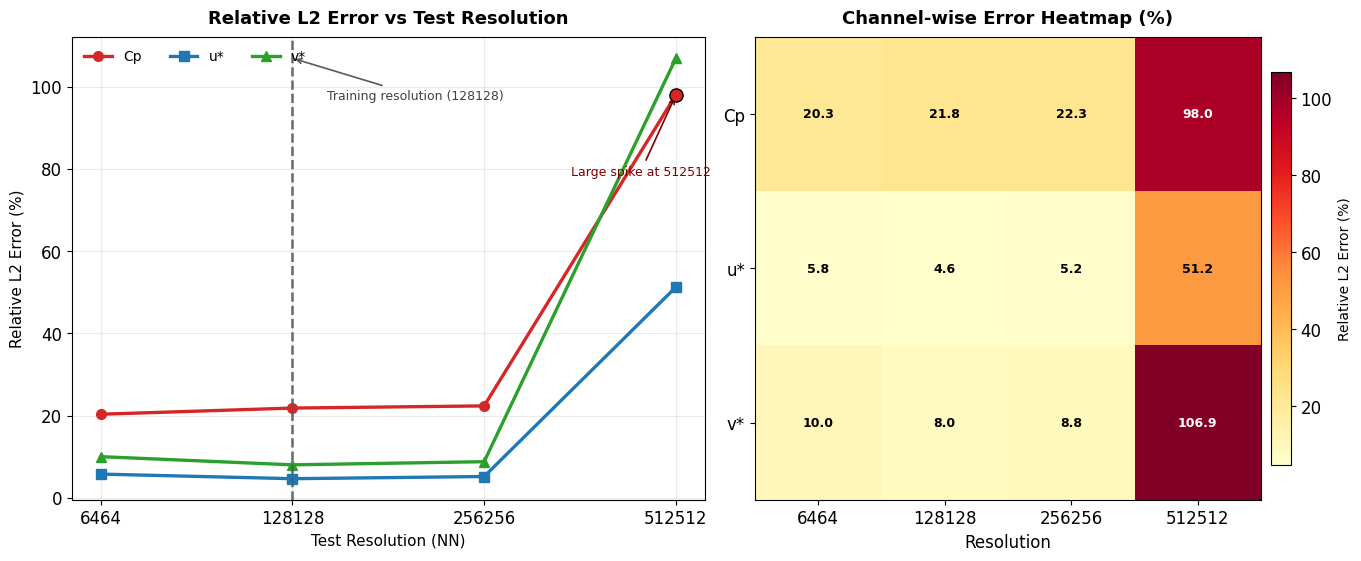

/opt/homebrew/Caskroom/miniforge/base/envs/aero/lib/python3.10/site-packages/neuralop/layers/spectral_convolution.py:428: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 64, 64, 33]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x = torch.fft.rfftn(x, norm=self.fft_norm, dim=fft_dims)
/opt/homebrew/Caskroom/miniforge/base/envs/aero/lib/python3.10/site-packages/neuralop/layers/spectral_convolution.py:521: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 64, 64, 64]. This behavior is deprecated, and in a future PyTorch release outputs will

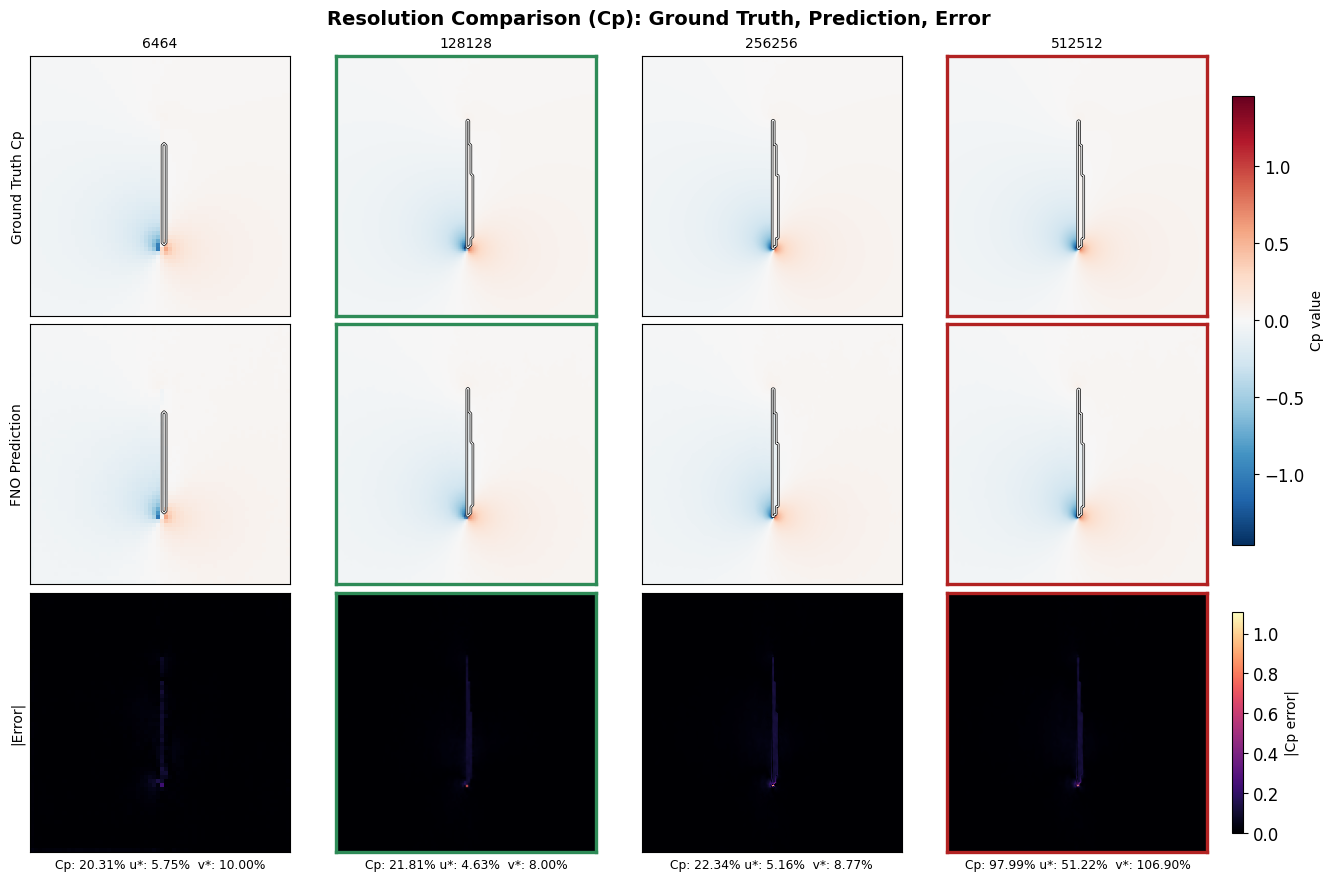

Saved: evaluation_v5/resolution_invariance.png
Saved: evaluation_v5/resolution_error_plot.png


In [12]:
#
# 11. Resolution Invariance Visualization
#

# Prepare data
res_list = [r['resolution'] for r in resolution_results]
cp_errors = [r['Cp'] * 100 for r in resolution_results]
us_errors = [r['u*'] * 100 for r in resolution_results]
vs_errors = [r['v*'] * 100 for r in resolution_results]

# ------------------------------------------------------------------------------
# Figure 1: Error trends + channel-resolution heatmap
# ------------------------------------------------------------------------------
fig_err, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(13.5, 5.5), constrained_layout=True, gridspec_kw={'width_ratios': [1.25, 1]})

# Left: line trend
ax_l.plot(res_list, cp_errors, marker='o', color='#D62728', lw=2.4, ms=7, label='Cp')
ax_l.plot(res_list, us_errors, marker='s', color='#1F77B4', lw=2.4, ms=7, label='u*')
ax_l.plot(res_list, vs_errors, marker='^', color='#2CA02C', lw=2.4, ms=7, label='v*')

ax_l.axvline(128, ls='--', color='0.35', lw=1.8, alpha=0.9)
ax_l.annotate('Training resolution (128128)', xy=(128, max(cp_errors + us_errors + vs_errors)),
              xytext=(145, max(cp_errors + us_errors + vs_errors) * 0.93),
              fontsize=9, color='0.25', ha='left', va='top',
              arrowprops=dict(arrowstyle='->', color='0.35', lw=1.2))

ax_l.scatter([512], [cp_errors[-1]], s=90, color='#D62728', edgecolor='k', zorder=5)
ax_l.annotate('Large spike at 512512', xy=(512, cp_errors[-1]),
              xytext=(350, cp_errors[-1] * 0.80),
              fontsize=9, color='#7f0000',
              arrowprops=dict(arrowstyle='->', lw=1.2, color='#7f0000'))

ax_l.set_title('Relative L2 Error vs Test Resolution', fontsize=13, fontweight='bold', pad=10)
ax_l.set_xlabel('Test Resolution (NN)', fontsize=11)
ax_l.set_ylabel('Relative L2 Error (%)', fontsize=11)
ax_l.set_xscale('log', base=2)
ax_l.set_xticks(res_list)
ax_l.set_xticklabels([f'{r}{r}' for r in res_list])
ax_l.grid(True, which='major', alpha=0.25)
ax_l.legend(loc='upper left', ncol=3, frameon=False)

# Right: channel x resolution heatmap (makes 512 spike obvious)
err_mat = np.array([
    cp_errors,
    us_errors,
    vs_errors
], dtype=np.float32)
im_h = ax_r.imshow(err_mat, cmap='YlOrRd', aspect='auto')
ax_r.set_title('Channel-wise Error Heatmap (%)', fontsize=13, fontweight='bold', pad=10)
ax_r.set_xticks(range(len(res_list)))
ax_r.set_xticklabels([f'{r}{r}' for r in res_list])
ax_r.set_yticks([0, 1, 2])
ax_r.set_yticklabels(['Cp', 'u*', 'v*'])
ax_r.set_xlabel('Resolution')

for rr in range(err_mat.shape[0]):
    for cc in range(err_mat.shape[1]):
        val = err_mat[rr, cc]
        txt_color = 'black' if val < np.max(err_mat) * 0.55 else 'white'
        ax_r.text(cc, rr, f'{val:.1f}', ha='center', va='center', fontsize=9, color=txt_color, fontweight='bold')

cbar_h = fig_err.colorbar(im_h, ax=ax_r, shrink=0.85, pad=0.02)
cbar_h.set_label('Relative L2 Error (%)', fontsize=10)

fig_err.savefig(os.path.join(OUTPUT_DIR, 'resolution_error_plot.png'), dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------------------
# Figure 2: Visual comparison at multiple resolutions (Cp) with strong outlines
# ------------------------------------------------------------------------------
sample_idx = 0
x_sample = x_test[sample_idx:sample_idx+1]
y_sample = y_test[sample_idx:sample_idx+1]

# Use a global color range so maps are directly comparable across resolutions
gt_all, pred_all, err_all, geom_all = [], [], [], []
for res in resolutions:
    x_res = F.interpolate(x_sample, size=(res, res), mode='bilinear', align_corners=False)
    y_res = F.interpolate(y_sample, size=(res, res), mode='bilinear', align_corners=False)
    with torch.no_grad():
        pred_res = model_v5(x_res.to(device)).cpu()

    gt = y_res[0, 0].numpy()
    pred = pred_res[0, 0].numpy()
    err = np.abs(gt - pred)
    geom = (x_res[0, 2].cpu().numpy() > 0.5).astype(float)

    gt_all.append(gt)
    pred_all.append(pred)
    err_all.append(err)
    geom_all.append(geom)

cp_lim = max(np.max(np.abs(g)) for g in gt_all + pred_all)
cp_lim = max(cp_lim, 0.1)
err_lim = max(np.max(e) for e in err_all)
err_lim = max(err_lim, 0.02)

fig_cmp, axes = plt.subplots(3, len(resolutions), figsize=(3.35 * len(resolutions), 8.7), constrained_layout=True)
fig_cmp.suptitle('Resolution Comparison (Cp): Ground Truth, Prediction, Error', fontsize=14, fontweight='bold')

for i, res in enumerate(resolutions):
    gt = gt_all[i]
    pred = pred_all[i]
    err = err_all[i]
    geom = geom_all[i]

    cp_err_pct = resolution_results[i]['Cp'] * 100
    u_err_pct = resolution_results[i]['u*'] * 100
    v_err_pct = resolution_results[i]['v*'] * 100

    ax0, ax1, ax2 = axes[0, i], axes[1, i], axes[2, i]

    im0 = ax0.imshow(gt, origin='lower', cmap='RdBu_r', vmin=-cp_lim, vmax=cp_lim)
    im1 = ax1.imshow(pred, origin='lower', cmap='RdBu_r', vmin=-cp_lim, vmax=cp_lim)
    im2 = ax2.imshow(err, origin='lower', cmap='magma', vmin=0, vmax=err_lim)

    # Strong dual contour for clear airfoil visibility
    for a in (ax0, ax1):
        a.contour(geom, levels=[0.5], colors='k', linewidths=1.8, origin='lower')
        a.contour(geom, levels=[0.5], colors='w', linewidths=0.8, origin='lower')

    ax0.set_title(f'{res}{res}', fontsize=10, pad=6)
    ax2.set_xlabel(f'Cp: {cp_err_pct:.2f}% u*: {u_err_pct:.2f}%  v*: {v_err_pct:.2f}%', fontsize=8.8)

    for a in (ax0, ax1, ax2):
        a.set_xticks([])
        a.set_yticks([])

    # Highlight training and problematic high-res columns
    if res == 128:
        col_color = '#2E8B57'
    elif res == 512:
        col_color = '#B22222'
    else:
        col_color = None

    if col_color is not None:
        for r in range(3):
            for side in ['bottom', 'top', 'left', 'right']:
                axes[r, i].spines[side].set_color(col_color)
                axes[r, i].spines[side].set_linewidth(2.4)

# Row labels
axes[0, 0].set_ylabel('Ground Truth Cp', fontsize=10)
axes[1, 0].set_ylabel('FNO Prediction', fontsize=10)
axes[2, 0].set_ylabel('|Error|', fontsize=10)

# Shared colorbars
cb1 = fig_cmp.colorbar(im0, ax=axes[:2, :], shrink=0.85, pad=0.02)
cb1.set_label('Cp value', fontsize=10)
cb2 = fig_cmp.colorbar(im2, ax=axes[2, :], shrink=0.85, pad=0.02)
cb2.set_label('|Cp error|', fontsize=10)

fig_cmp.savefig(os.path.join(OUTPUT_DIR, 'resolution_invariance.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f'Saved: {OUTPUT_DIR}/resolution_invariance.png')
print(f'Saved: {OUTPUT_DIR}/resolution_error_plot.png')


---
## Section 5: Paper-Ready Visualizations

/opt/homebrew/Caskroom/miniforge/base/envs/aero/lib/python3.10/site-packages/neuralop/layers/spectral_convolution.py:428: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [4, 64, 128, 65]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x = torch.fft.rfftn(x, norm=self.fft_norm, dim=fft_dims)
/opt/homebrew/Caskroom/miniforge/base/envs/aero/lib/python3.10/site-packages/neuralop/layers/spectral_convolution.py:521: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [4, 64, 128, 128]. This behavior is deprecated, and in a future PyTorch release outputs w

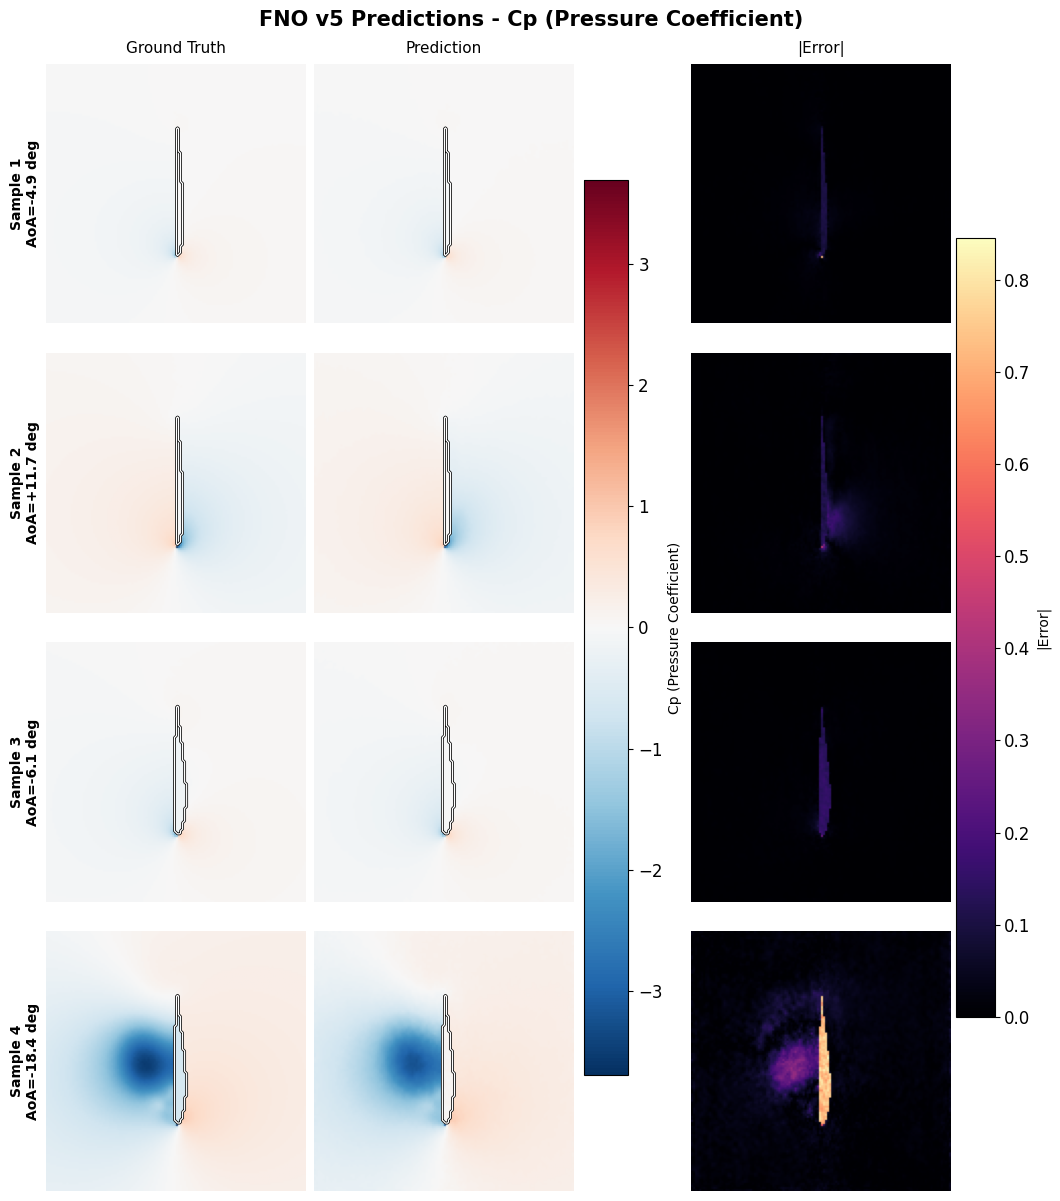

Saved: evaluation_v5/predictions_cp.png


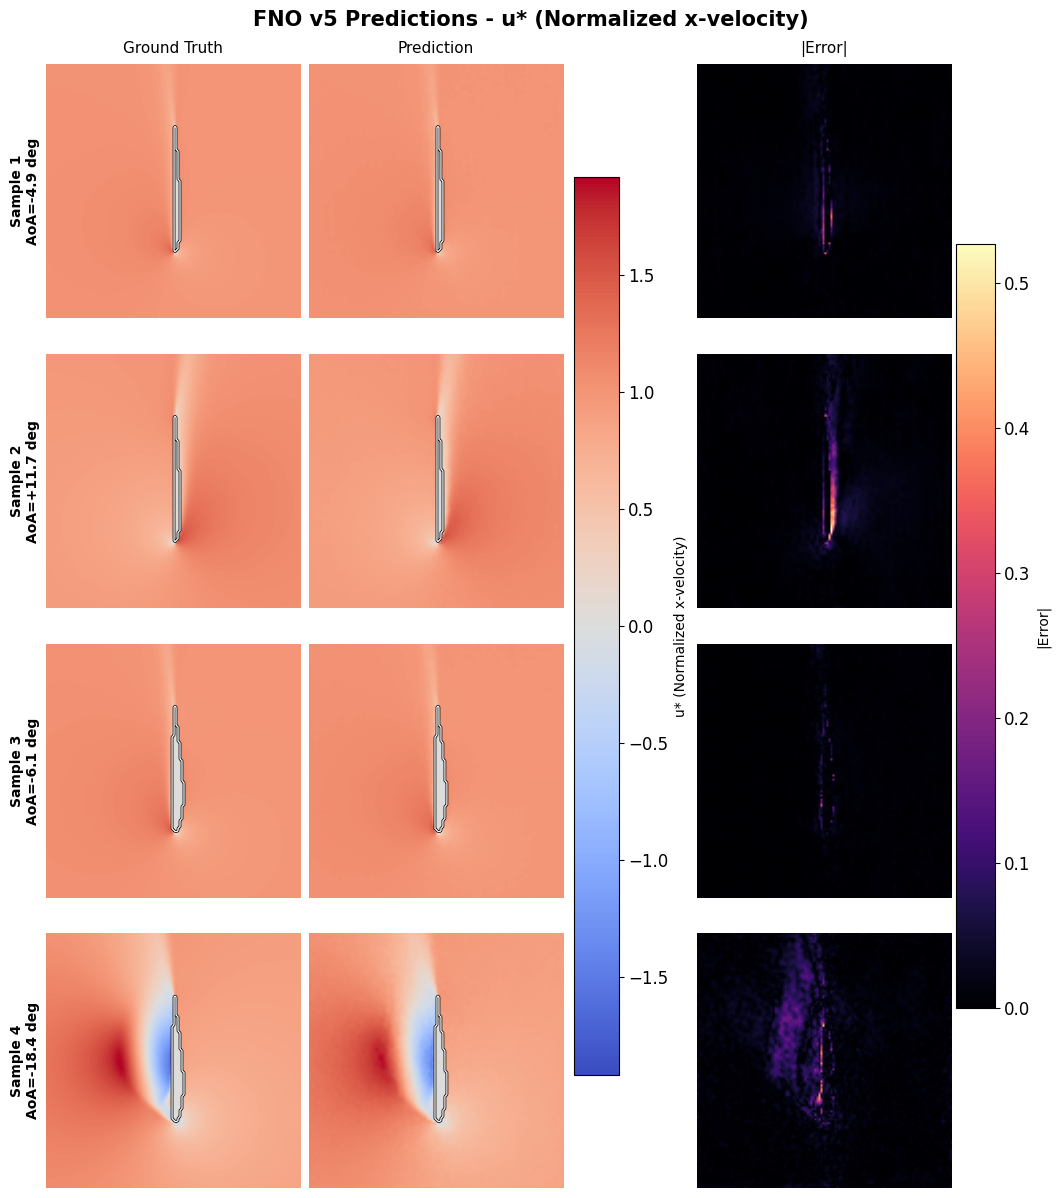

Saved: evaluation_v5/predictions_u.png


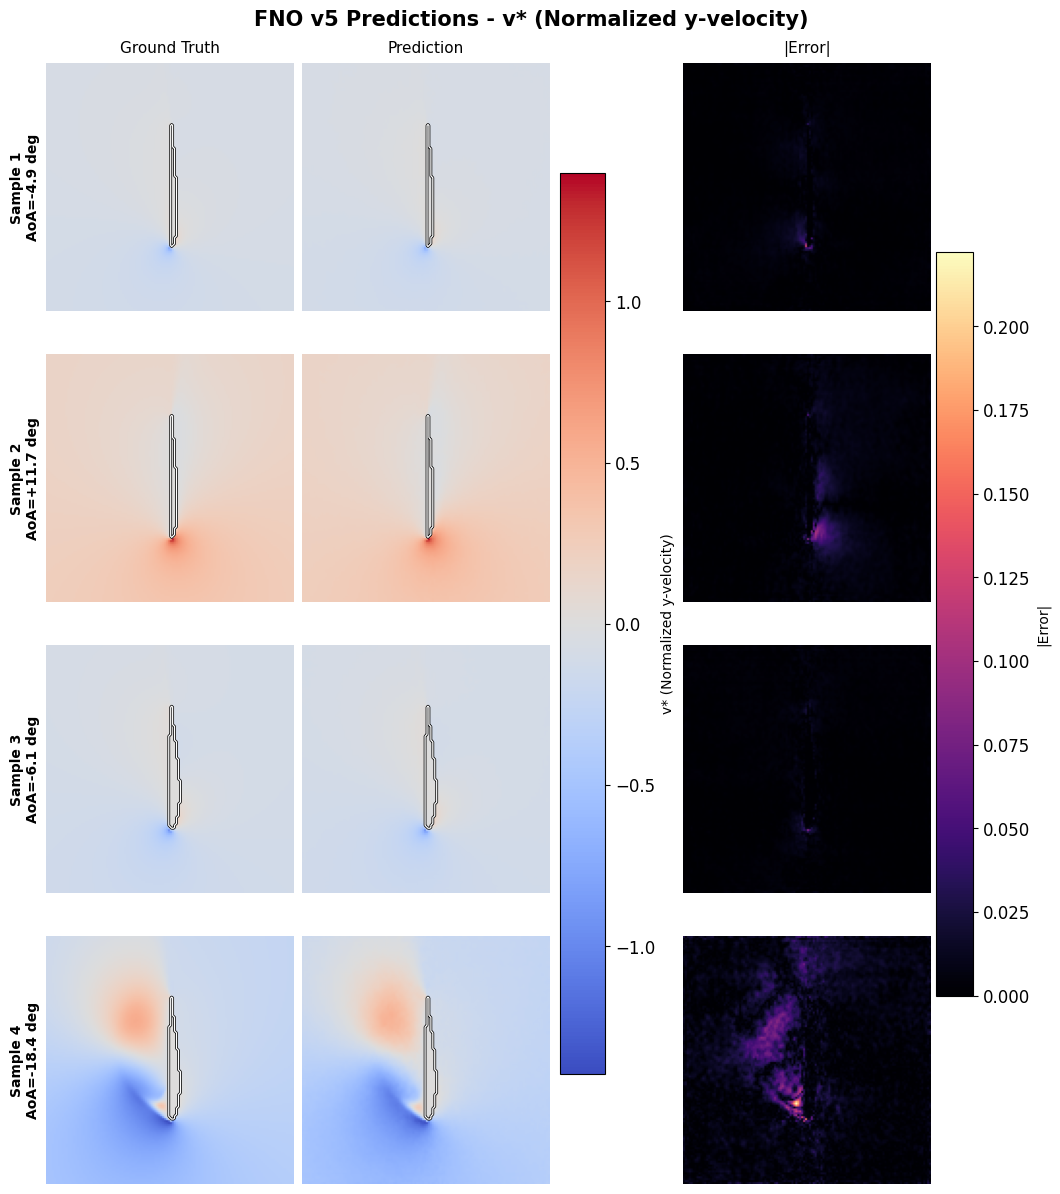

Saved: evaluation_v5/predictions_v.png


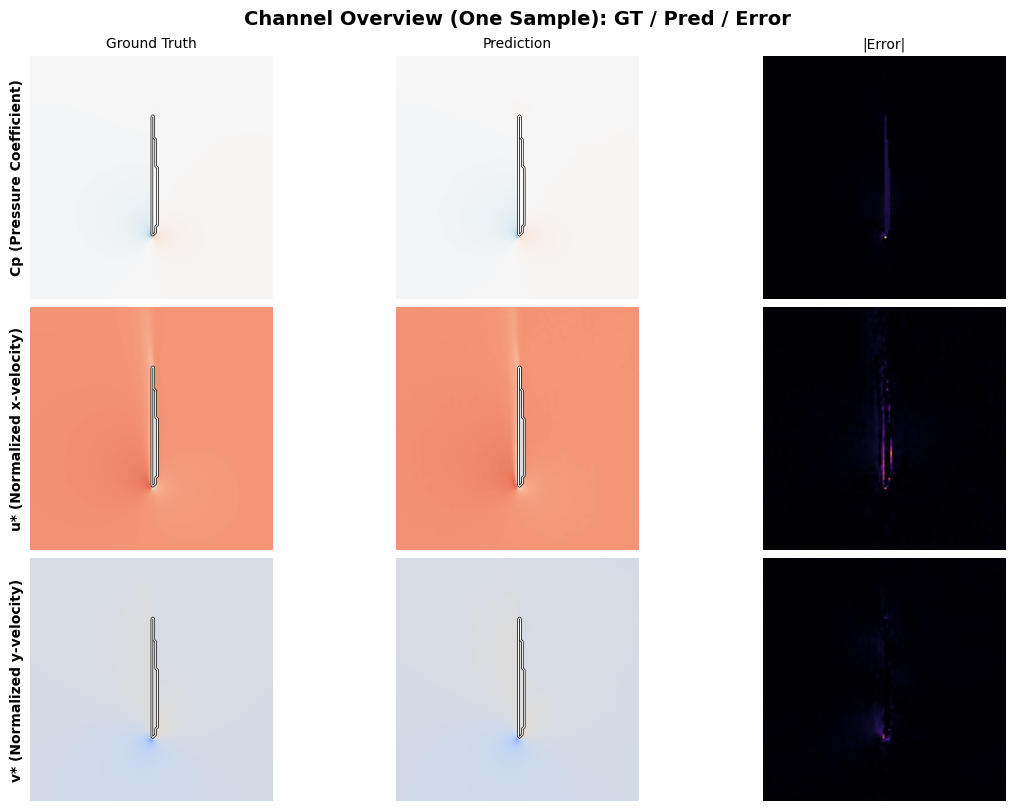

Saved: evaluation_v5/comprehensive_predictions.png


In [13]:
#
# 12. Comprehensive Prediction Visualization
#

# Get diverse samples from test set
test_iter = iter(test_loader)
x_batch1, y_batch1 = next(test_iter)
x_batch2, y_batch2 = next(test_iter)
x_samples = torch.cat([x_batch1[:2], x_batch2[:2]], dim=0)
y_samples = torch.cat([y_batch1[:2], y_batch2[:2]], dim=0)

with torch.no_grad():
    pred_samples = model_v5(x_samples.to(device)).cpu()

# Binary geometry mask used for airfoil outline overlay
geom_masks = (x_samples[:, 2].numpy() > 0.5).astype(float)

# Build separate channel-wise figures (cleaner for paper)
channel_specs = [
    (0, 'Cp (Pressure Coefficient)', 'RdBu_r', 'cp'),
    (1, 'u* (Normalized x-velocity)', 'coolwarm', 'u'),
    (2, 'v* (Normalized y-velocity)', 'coolwarm', 'v'),
]

for ch_idx, ch_title, cmap, short_name in channel_specs:
    gt_ch = y_samples[:, ch_idx].numpy()
    pred_ch = pred_samples[:, ch_idx].numpy()
    err_ch = np.abs(gt_ch - pred_ch)

    # Consistent scales across all shown samples for this channel
    vlim = max(np.max(np.abs(gt_ch)), np.max(np.abs(pred_ch)), 0.1)
    elim = max(np.max(err_ch), 0.02)

    fig, axes = plt.subplots(4, 3, figsize=(10.5, 12.0), constrained_layout=True)
    fig.suptitle(f'FNO v5 Predictions - {ch_title}', fontsize=15, fontweight='bold')

    for sample_idx in range(4):
        gt = y_samples[sample_idx, ch_idx].numpy()
        pred = pred_samples[sample_idx, ch_idx].numpy()
        err = np.abs(gt - pred)
        geom = geom_masks[sample_idx]

        ux = x_samples[sample_idx, 0].mean().item()
        uy = x_samples[sample_idx, 1].mean().item()
        aoa = np.degrees(np.arctan2(uy, ux))

        ax_gt = axes[sample_idx, 0]
        ax_pr = axes[sample_idx, 1]
        ax_er = axes[sample_idx, 2]

        im0 = ax_gt.imshow(gt, origin='lower', cmap=cmap, vmin=-vlim, vmax=vlim)
        ax_pr.imshow(pred, origin='lower', cmap=cmap, vmin=-vlim, vmax=vlim)
        im2 = ax_er.imshow(err, origin='lower', cmap='magma', vmin=0, vmax=elim)

        # Make airfoil clearly visible in GT/Prediction panels:
        # black outer contour + white inner contour for high contrast on any colormap.
        for ax_vis in (ax_gt, ax_pr):
            ax_vis.contour(geom, levels=[0.5], colors='k', linewidths=2.0, origin='lower')
            ax_vis.contour(geom, levels=[0.5], colors='w', linewidths=0.9, origin='lower')

        for j in range(3):
            axes[sample_idx, j].set_xticks([])
            axes[sample_idx, j].set_yticks([])
            for side in ['top', 'right', 'bottom', 'left']:
                axes[sample_idx, j].spines[side].set_visible(False)

        axes[sample_idx, 0].set_ylabel(
            f'Sample {sample_idx + 1}\nAoA={aoa:+.1f} deg',
            fontsize=10,
            fontweight='bold'
        )

    axes[0, 0].set_title('Ground Truth', fontsize=11, pad=8)
    axes[0, 1].set_title('Prediction', fontsize=11, pad=8)
    axes[0, 2].set_title('|Error|', fontsize=11, pad=8)

    cb_field = fig.colorbar(im0, ax=axes[:, :2], shrink=0.78, pad=0.02)
    cb_field.set_label(ch_title, fontsize=10)

    cb_err = fig.colorbar(im2, ax=axes[:, 2], shrink=0.78, pad=0.02)
    cb_err.set_label('|Error|', fontsize=10)

    out_path = os.path.join(OUTPUT_DIR, f'predictions_{short_name}.png')
    plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved: {out_path}')

# Keep compact combined overview for compatibility
fig, axes = plt.subplots(3, 3, figsize=(11, 8), constrained_layout=True)
fig.suptitle('Channel Overview (One Sample): GT / Pred / Error', fontsize=14, fontweight='bold')

sample_idx = 0
geom = geom_masks[sample_idx]
for row, (ch_idx, ch_title, cmap, _) in enumerate(channel_specs):
    gt = y_samples[sample_idx, ch_idx].numpy()
    pred = pred_samples[sample_idx, ch_idx].numpy()
    err = np.abs(gt - pred)

    vlim = max(
        np.max(np.abs(y_samples[:, ch_idx].numpy())),
        np.max(np.abs(pred_samples[:, ch_idx].numpy())),
        0.1
    )
    elim = max(
        np.max(np.abs(y_samples[:, ch_idx].numpy() - pred_samples[:, ch_idx].numpy())),
        0.02
    )

    ax_gt = axes[row, 0]
    ax_pr = axes[row, 1]
    ax_er = axes[row, 2]

    ax_gt.imshow(gt, origin='lower', cmap=cmap, vmin=-vlim, vmax=vlim)
    ax_pr.imshow(pred, origin='lower', cmap=cmap, vmin=-vlim, vmax=vlim)
    ax_er.imshow(err, origin='lower', cmap='magma', vmin=0, vmax=elim)

    for ax_vis in (ax_gt, ax_pr):
        ax_vis.contour(geom, levels=[0.5], colors='k', linewidths=1.8, origin='lower')
        ax_vis.contour(geom, levels=[0.5], colors='w', linewidths=0.8, origin='lower')

    axes[row, 0].set_ylabel(ch_title, fontsize=10, fontweight='bold')

    for c in range(3):
        axes[row, c].set_xticks([])
        axes[row, c].set_yticks([])
        for side in ['top', 'right', 'bottom', 'left']:
            axes[row, c].spines[side].set_visible(False)

axes[0, 0].set_title('Ground Truth', fontsize=10)
axes[0, 1].set_title('Prediction', fontsize=10)
axes[0, 2].set_title('|Error|', fontsize=10)

plt.savefig(os.path.join(OUTPUT_DIR, 'comprehensive_predictions.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {OUTPUT_DIR}/comprehensive_predictions.png')


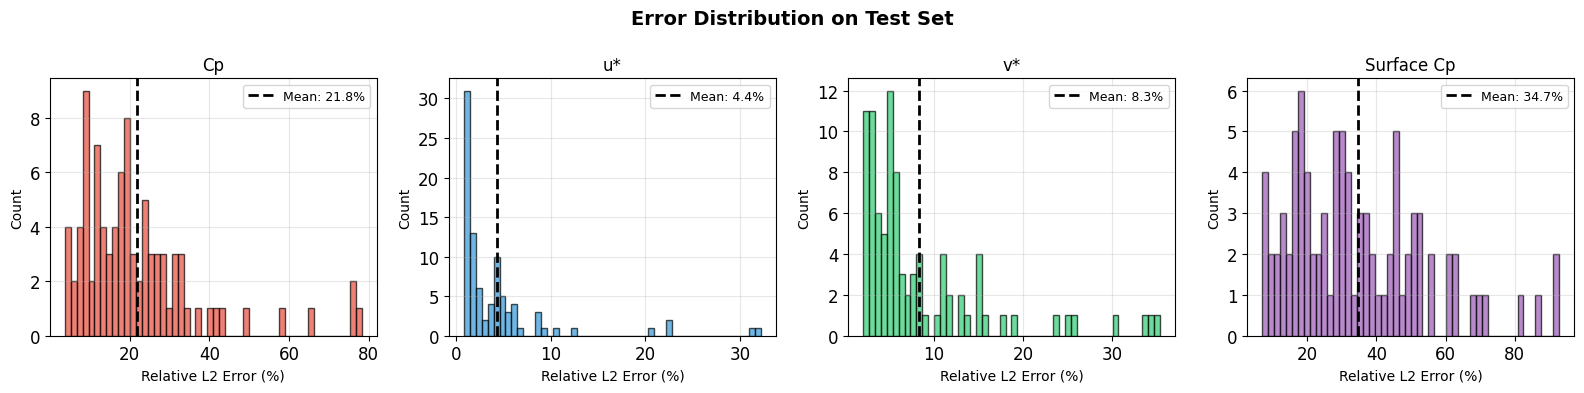

Saved: evaluation_v5/error_distributions.png


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# 13. Error Distribution Histograms
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Error Distribution on Test Set', fontsize=14, fontweight='bold')

ch_names = ['Cp', 'u*', 'v*', 'Surface Cp']
ch_data = results_v5_test['ch_errors'] + [results_v5_test['surface_cp_errors']]
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']

for i, (name, data, color) in enumerate(zip(ch_names, ch_data, colors)):
    ax = axes[i]
    data_pct = [d * 100 for d in data]
    
    ax.hist(data_pct, bins=50, color=color, edgecolor='black', alpha=0.7)
    ax.axvline(np.mean(data_pct), color='black', linestyle='--', lw=2, label=f'Mean: {np.mean(data_pct):.1f}%')
    ax.set_xlabel('Relative L2 Error (%)', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title(name, fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'error_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUTPUT_DIR}/error_distributions.png')

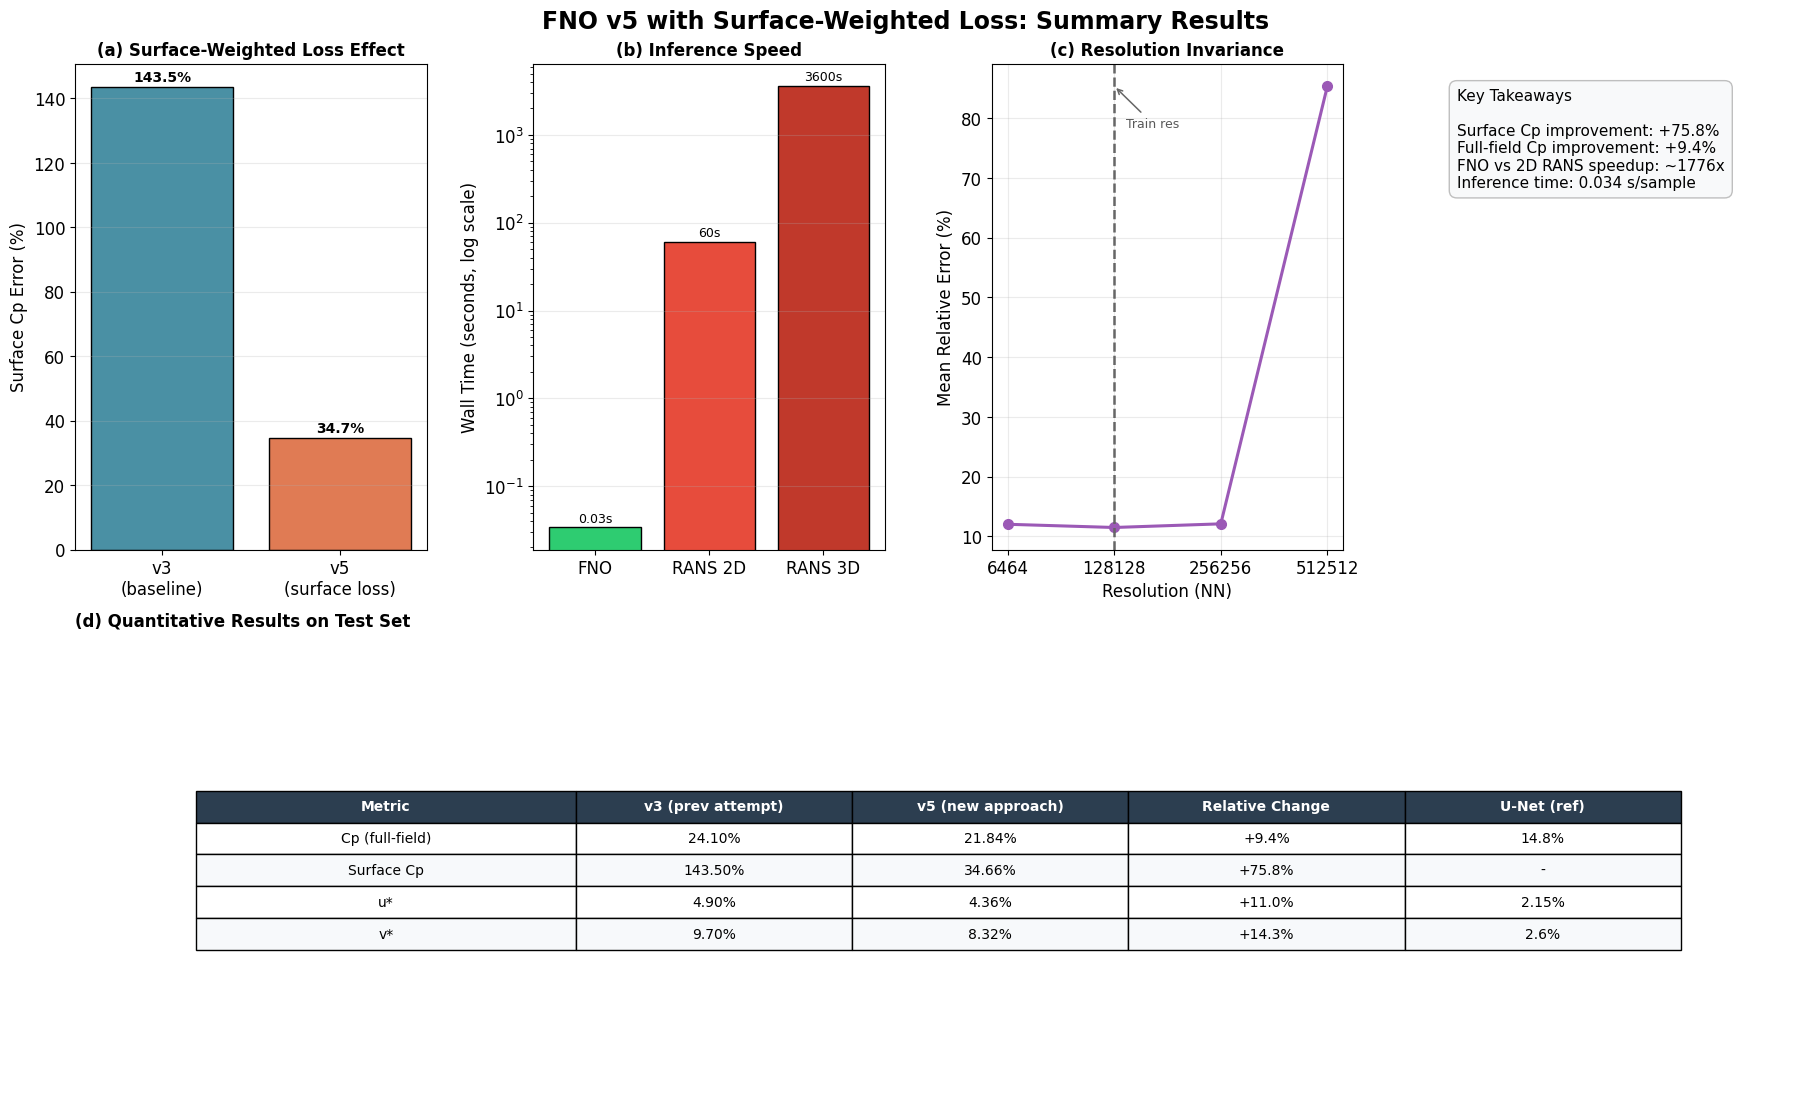

Saved: evaluation_v5/paper_summary_figure.png


In [15]:
#
# 14. Summary Figure for Paper
#

fig = plt.figure(figsize=(18, 11), constrained_layout=True)
gs = GridSpec(2, 4, figure=fig, height_ratios=[1.0, 0.95], width_ratios=[1, 1, 1, 1])
fig.suptitle('FNO v5 with Surface-Weighted Loss: Summary Results', fontsize=17, fontweight='bold')

# (a) Surface loss ablation
ax = fig.add_subplot(gs[0, 0])
v3_surf = v3_baseline['Surface_Cp'] * 100
v5_surf = results_v5_test['Surface_Cp'] * 100
ax.set_ylabel('Surface Cp Error (%)')
bars = ax.bar(['v3\n(baseline)', 'v5\n(surface loss)'], [v3_surf, v5_surf], color=['#4A90A4', '#E07B54'], edgecolor='black')
ax.set_title('(a) Surface-Weighted Loss Effect', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.25)
for bar in bars:
    ax.annotate(f'{bar.get_height():.1f}%', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=10, fontweight='bold')

# (b) Inference speed
ax = fig.add_subplot(gs[0, 1])
methods = ['FNO', 'RANS 2D', 'RANS 3D']
times = [fno_time_s, 60, 3600]
colors_speed = ['#2ECC71', '#E74C3C', '#C0392B']
bars = ax.bar(methods, times, color=colors_speed, edgecolor='black')
ax.set_yscale('log')
ax.set_ylabel('Wall Time (seconds, log scale)')
ax.set_title('(b) Inference Speed', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.25)
for bar, val in zip(bars, times):
    label = f'{val:.2f}s' if val < 1 else f'{val:.0f}s'
    ax.annotate(label, xy=(bar.get_x() + bar.get_width()/2, val),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=9)

# (c) Resolution invariance
ax = fig.add_subplot(gs[0, 2])
res_list = [r['resolution'] for r in resolution_results]
mean_errors = [r['mean'] * 100 for r in resolution_results]
ax.plot(res_list, mean_errors, marker='o', color='#9B59B6', lw=2.2, markersize=7)
ax.axvline(128, ls='--', color='0.4', lw=1.8)
ax.annotate('Train res', xy=(128, max(mean_errors)), xytext=(138, max(mean_errors)*0.92),
            arrowprops=dict(arrowstyle='->', lw=1.1, color='0.4'), fontsize=9, color='0.35')
ax.set_xlabel('Resolution (NN)')
ax.set_ylabel('Mean Relative Error (%)')
ax.set_title('(c) Resolution Invariance', fontsize=12, fontweight='bold')
ax.set_xscale('log', base=2)
ax.set_xticks(res_list)
ax.set_xticklabels([f'{r}{r}' for r in res_list])
ax.grid(alpha=0.25)

# Key metrics card (unlabeled, supporting info)
ax = fig.add_subplot(gs[0, 3])
ax.axis('off')
cp_impr = (v3_baseline['Cp'] - results_v5_test['Cp']) / (v3_baseline['Cp'] + 1e-12) * 100
surf_impr = (v3_baseline['Surface_Cp'] - results_v5_test['Surface_Cp']) / (v3_baseline['Surface_Cp'] + 1e-12) * 100
speedup_2d = 60 / max(fno_time_s, 1e-6)
card_text = (
    'Key Takeaways\n\n'
    f'Surface Cp improvement: {surf_impr:+.1f}%\n'
    f'Full-field Cp improvement: {cp_impr:+.1f}%\n'
    f'FNO vs 2D RANS speedup: ~{speedup_2d:.0f}x\n'
    f'Inference time: {fno_time_s:.3f} s/sample'
)
ax.text(0.02, 0.95, card_text, va='top', ha='left', fontsize=11,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#F8F9FA', edgecolor='0.75'))

# (d) Quantitative results table
ax_table = fig.add_subplot(gs[1, :])
ax_table.axis('off')

table_data = [
    ['Metric', 'v3 (prev attempt)', 'v5 (new approach)', 'Relative Change', 'U-Net (ref)'],
    ['Cp (full-field)',
     f'{v3_baseline["Cp"]*100:.2f}%',
     f'{results_v5_test["Cp"]*100:.2f}%',
     f'{(v3_baseline["Cp"]-results_v5_test["Cp"])/(v3_baseline["Cp"]+1e-12)*100:+.1f}%',
     '14.8%'],
    ['Surface Cp',
     f'{v3_baseline["Surface_Cp"]*100:.2f}%',
     f'{results_v5_test["Surface_Cp"]*100:.2f}%',
     f'{(v3_baseline["Surface_Cp"]-results_v5_test["Surface_Cp"])/(v3_baseline["Surface_Cp"]+1e-12)*100:+.1f}%',
     '-'],
    ['u*',
     f'{v3_baseline["u*"]*100:.2f}%',
     f'{results_v5_test["u*"]*100:.2f}%',
     f'{(v3_baseline["u*"]-results_v5_test["u*"])/(v3_baseline["u*"]+1e-12)*100:+.1f}%',
     '2.15%'],
    ['v*',
     f'{v3_baseline["v*"]*100:.2f}%',
     f'{results_v5_test["v*"]*100:.2f}%',
     f'{(v3_baseline["v*"]-results_v5_test["v*"])/(v3_baseline["v*"]+1e-12)*100:+.1f}%',
     '2.6%'],
]

table = ax_table.table(cellText=table_data, loc='center', cellLoc='center',
                       colWidths=[0.22, 0.16, 0.16, 0.16, 0.16])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.0, 1.55)

for j in range(5):
    table[(0, j)].set_facecolor('#2C3E50')
    table[(0, j)].set_text_props(color='white', fontweight='bold')

for r in range(1, len(table_data)):
    if r % 2 == 0:
        for c in range(5):
            table[(r, c)].set_facecolor('#F7F9FB')

ax_table.set_title('(d) Quantitative Results on Test Set', fontsize=12, fontweight='bold', loc='left', pad=10)

plt.savefig(os.path.join(OUTPUT_DIR, 'paper_summary_figure.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {OUTPUT_DIR}/paper_summary_figure.png')
